# 01. Derive ROI masks based on meta-analytic map of language from Neurosynth

This notebook shows how the ROI masks for the language regions and right hemisphere homologues were found

Inputs:
- Glasser 2021 atlas in MNI space as provided by AFNI 
- NeuroSynth association atlas results

Steps:
1. Find significant parcels associated with language by parcellating the NeuroSynth language association results
2. Make masks of associated parcels by binarizing and smoothing.
3. Show process.

Outputs:
- 4 ROI masks (lIFG, lSTG, rIFG, and rSTG)

Written by: Jitse S. Amelink

Last edited: 2024/12/17

# Setting up

In [3]:
import os
from nilearn import plotting, image
from nilearn.maskers import NiftiLabelsMasker
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt
import nibabel as nb
import pandas as pd
from subprocess import run

#paths
work_path = "/data/clusterfs/lag/projects/lg-ukbiobank/working_data/imaging_data/CONGRADS_rest/mask/"

#save masks
save_all=True

In [4]:
def make_mask(parcels, atlas_file, all_parcels, bin_thresh, brain_mask_fn):
    """
    Defines mask based on parcel nos provided as input.
    Returns nifti img
    """
    #load atlas image
    atlas_img = image.load_img(atlas_file)
    
    #get data
    roi_mask = image.get_data(atlas_img)
    
    # get brain mask
    brain_mask = image.load_img(brain_mask_fn)

    
    #set parcels to 1
    print("Including parcels in mask: ", parcels)
    for i in all_parcels: # range(1, int(no_parcels+1), 1):
        if i in parcels:
            roi_mask[roi_mask == i] = np.array([1])
        else:
            roi_mask[roi_mask == i] = 0
    
    #return image
    roi_mask_img = image.new_img_like(atlas_img, roi_mask, copy_header=True)
    
    #return binarized image
    return image.binarize_img(roi_mask_img, threshold=bin_thresh, mask_img=brain_mask)

# Get statistics

In [5]:
atlas_in = "/data/workspaces/lag/workspaces/lg-ukbiobank/projects/CONGRADS_rest/atlas/MNI_Glasser_HCP_v1.0.nii.gz"
atlas_img = image.load_img(atlas_in)

lang_map = "/data/workspaces/lag/workspaces/lg-ukbiobank/projects/CONGRADS_rest/stat_maps/language_association-test_z_FDR_0.01_231027.nii.gz"

mask_fn_1mm = "/data/clusterfs/lag/projects/lg-ukbiobank/working_data/imaging_data/CONGRADS_rest/mask/brain_masks/thickness_mask_1mm.nii.gz"
mask_fn_2mm = "/data/clusterfs/lag/projects/lg-ukbiobank/working_data/imaging_data/CONGRADS_rest/mask/brain_masks/thickness_mask_2mm.nii.gz"

#getting upper threshold
p_thresh = .99999999
z_thresh = st.norm.ppf(p_thresh)

# process association map
#load masker
masker = NiftiLabelsMasker(labels_img=atlas_img)

#apply mask
association_stats = masker.fit_transform(lang_map)

#threshold non-sig parcels
association_stats[association_stats < z_thresh] = 0
print(association_stats.shape)

#load image and put values in image data. i counts from 0 and atlas from 1, so i+1
association_stat_map = image.get_data(atlas_img)
for i in range(180):
    association_stat_map[ association_stat_map == i+1 ] = association_stats[0, i]

for i in range(180, 360, 1):
    association_stat_map[ association_stat_map == i+1+820 ] = association_stats[0, i]
    
association_stat_img = image.new_img_like(atlas_img, association_stat_map, copy_header=True)

(1, 360)


# Make mask

In [7]:
sig_parcels = np.where(association_stats)[1]

l_ifg = [x+1 for x in sig_parcels[sig_parcels < 100]]
l_stg = [x+1 for x in sig_parcels[sig_parcels > 100]]
print(l_ifg)
print(l_stg)
    
r_ifg = [x + 1000 for x in l_ifg]
r_stg = [x + 1000 for x in l_stg]

all_parcels = list(range(1, 181, 1))
all_parcels = all_parcels + [x+1000 for x in all_parcels]

[74, 75, 76, 79, 81, 82]
[125, 128, 129, 130, 139]


In [8]:
l_ifg_mask = make_mask(parcels = l_ifg, atlas_file = atlas_in, all_parcels = all_parcels, bin_thresh="99%", brain_mask_fn = mask_fn_1mm)
l_stg_mask = make_mask(parcels = l_stg, atlas_file = atlas_in, all_parcels = all_parcels, bin_thresh="99%", brain_mask_fn = mask_fn_1mm)
r_ifg_mask = make_mask(parcels = r_ifg, atlas_file = atlas_in, all_parcels = all_parcels, bin_thresh="99%", brain_mask_fn = mask_fn_1mm)
r_stg_mask = make_mask(parcels = r_stg, atlas_file = atlas_in, all_parcels = all_parcels, bin_thresh="99%", brain_mask_fn = mask_fn_1mm)

#save masks
if save_all:
    l_ifg_mask.to_filename(os.path.join(work_path, "roi_lifg_glasser_1mm.nii.gz"))
    l_stg_mask.to_filename(os.path.join(work_path, "roi_lstg_glasser_1mm.nii.gz")) 
    r_ifg_mask.to_filename(os.path.join(work_path, "roi_rifg_glasser_1mm.nii.gz"))
    r_stg_mask.to_filename(os.path.join(work_path, "roi_rstg_glasser_1mm.nii.gz")) 

Including parcels in mask:  [74, 75, 76, 79, 81, 82]


/home/jitame/bin/anaconda3/envs/results_env/lib/python3.10/site-packages/nilearn/image/image.py:1041: UserWarning: Data array used to create a new image contains 64-bit ints. This is likely due to creating the array with numpy and passing `int` as the `dtype`. Many tools such as FSL and SPM cannot deal with int64 in Nifti images, so for compatibility the data has been converted to int32.
  return new_img_like(niimg, result, niimg.affine)


Including parcels in mask:  [125, 128, 129, 130, 139]


/home/jitame/bin/anaconda3/envs/results_env/lib/python3.10/site-packages/nilearn/image/image.py:1041: UserWarning: Data array used to create a new image contains 64-bit ints. This is likely due to creating the array with numpy and passing `int` as the `dtype`. Many tools such as FSL and SPM cannot deal with int64 in Nifti images, so for compatibility the data has been converted to int32.
  return new_img_like(niimg, result, niimg.affine)


Including parcels in mask:  [1074, 1075, 1076, 1079, 1081, 1082]


/home/jitame/bin/anaconda3/envs/results_env/lib/python3.10/site-packages/nilearn/image/image.py:1041: UserWarning: Data array used to create a new image contains 64-bit ints. This is likely due to creating the array with numpy and passing `int` as the `dtype`. Many tools such as FSL and SPM cannot deal with int64 in Nifti images, so for compatibility the data has been converted to int32.
  return new_img_like(niimg, result, niimg.affine)


Including parcels in mask:  [1125, 1128, 1129, 1130, 1139]


/home/jitame/bin/anaconda3/envs/results_env/lib/python3.10/site-packages/nilearn/image/image.py:1041: UserWarning: Data array used to create a new image contains 64-bit ints. This is likely due to creating the array with numpy and passing `int` as the `dtype`. Many tools such as FSL and SPM cannot deal with int64 in Nifti images, so for compatibility the data has been converted to int32.
  return new_img_like(niimg, result, niimg.affine)


In [17]:
for roi in lifg lstg rifg rstg; do
flirt -in roi_${roi}_glasser_1mm.nii.gz -ref $FSLDIR/data/standard/MNI152_T1_2mm.nii.gz -interp nearestneighbour -applyxfm -usesqform -out roi_${roi}_glasser_temp.nii.gz

fslmaths roi_${roi}_glasser_temp.nii.gz -dilM -ero -mas $FSLDIR/data/standard/MNI152_T1_2mm_brain_mask.nii.gz roi_${roi}.nii.gz
done
   #run(cmd, shell=True)

/bin/sh: flirt: command not found
/bin/sh: flirt: command not found
/bin/sh: flirt: command not found
/bin/sh: flirt: command not found


# Visualize process

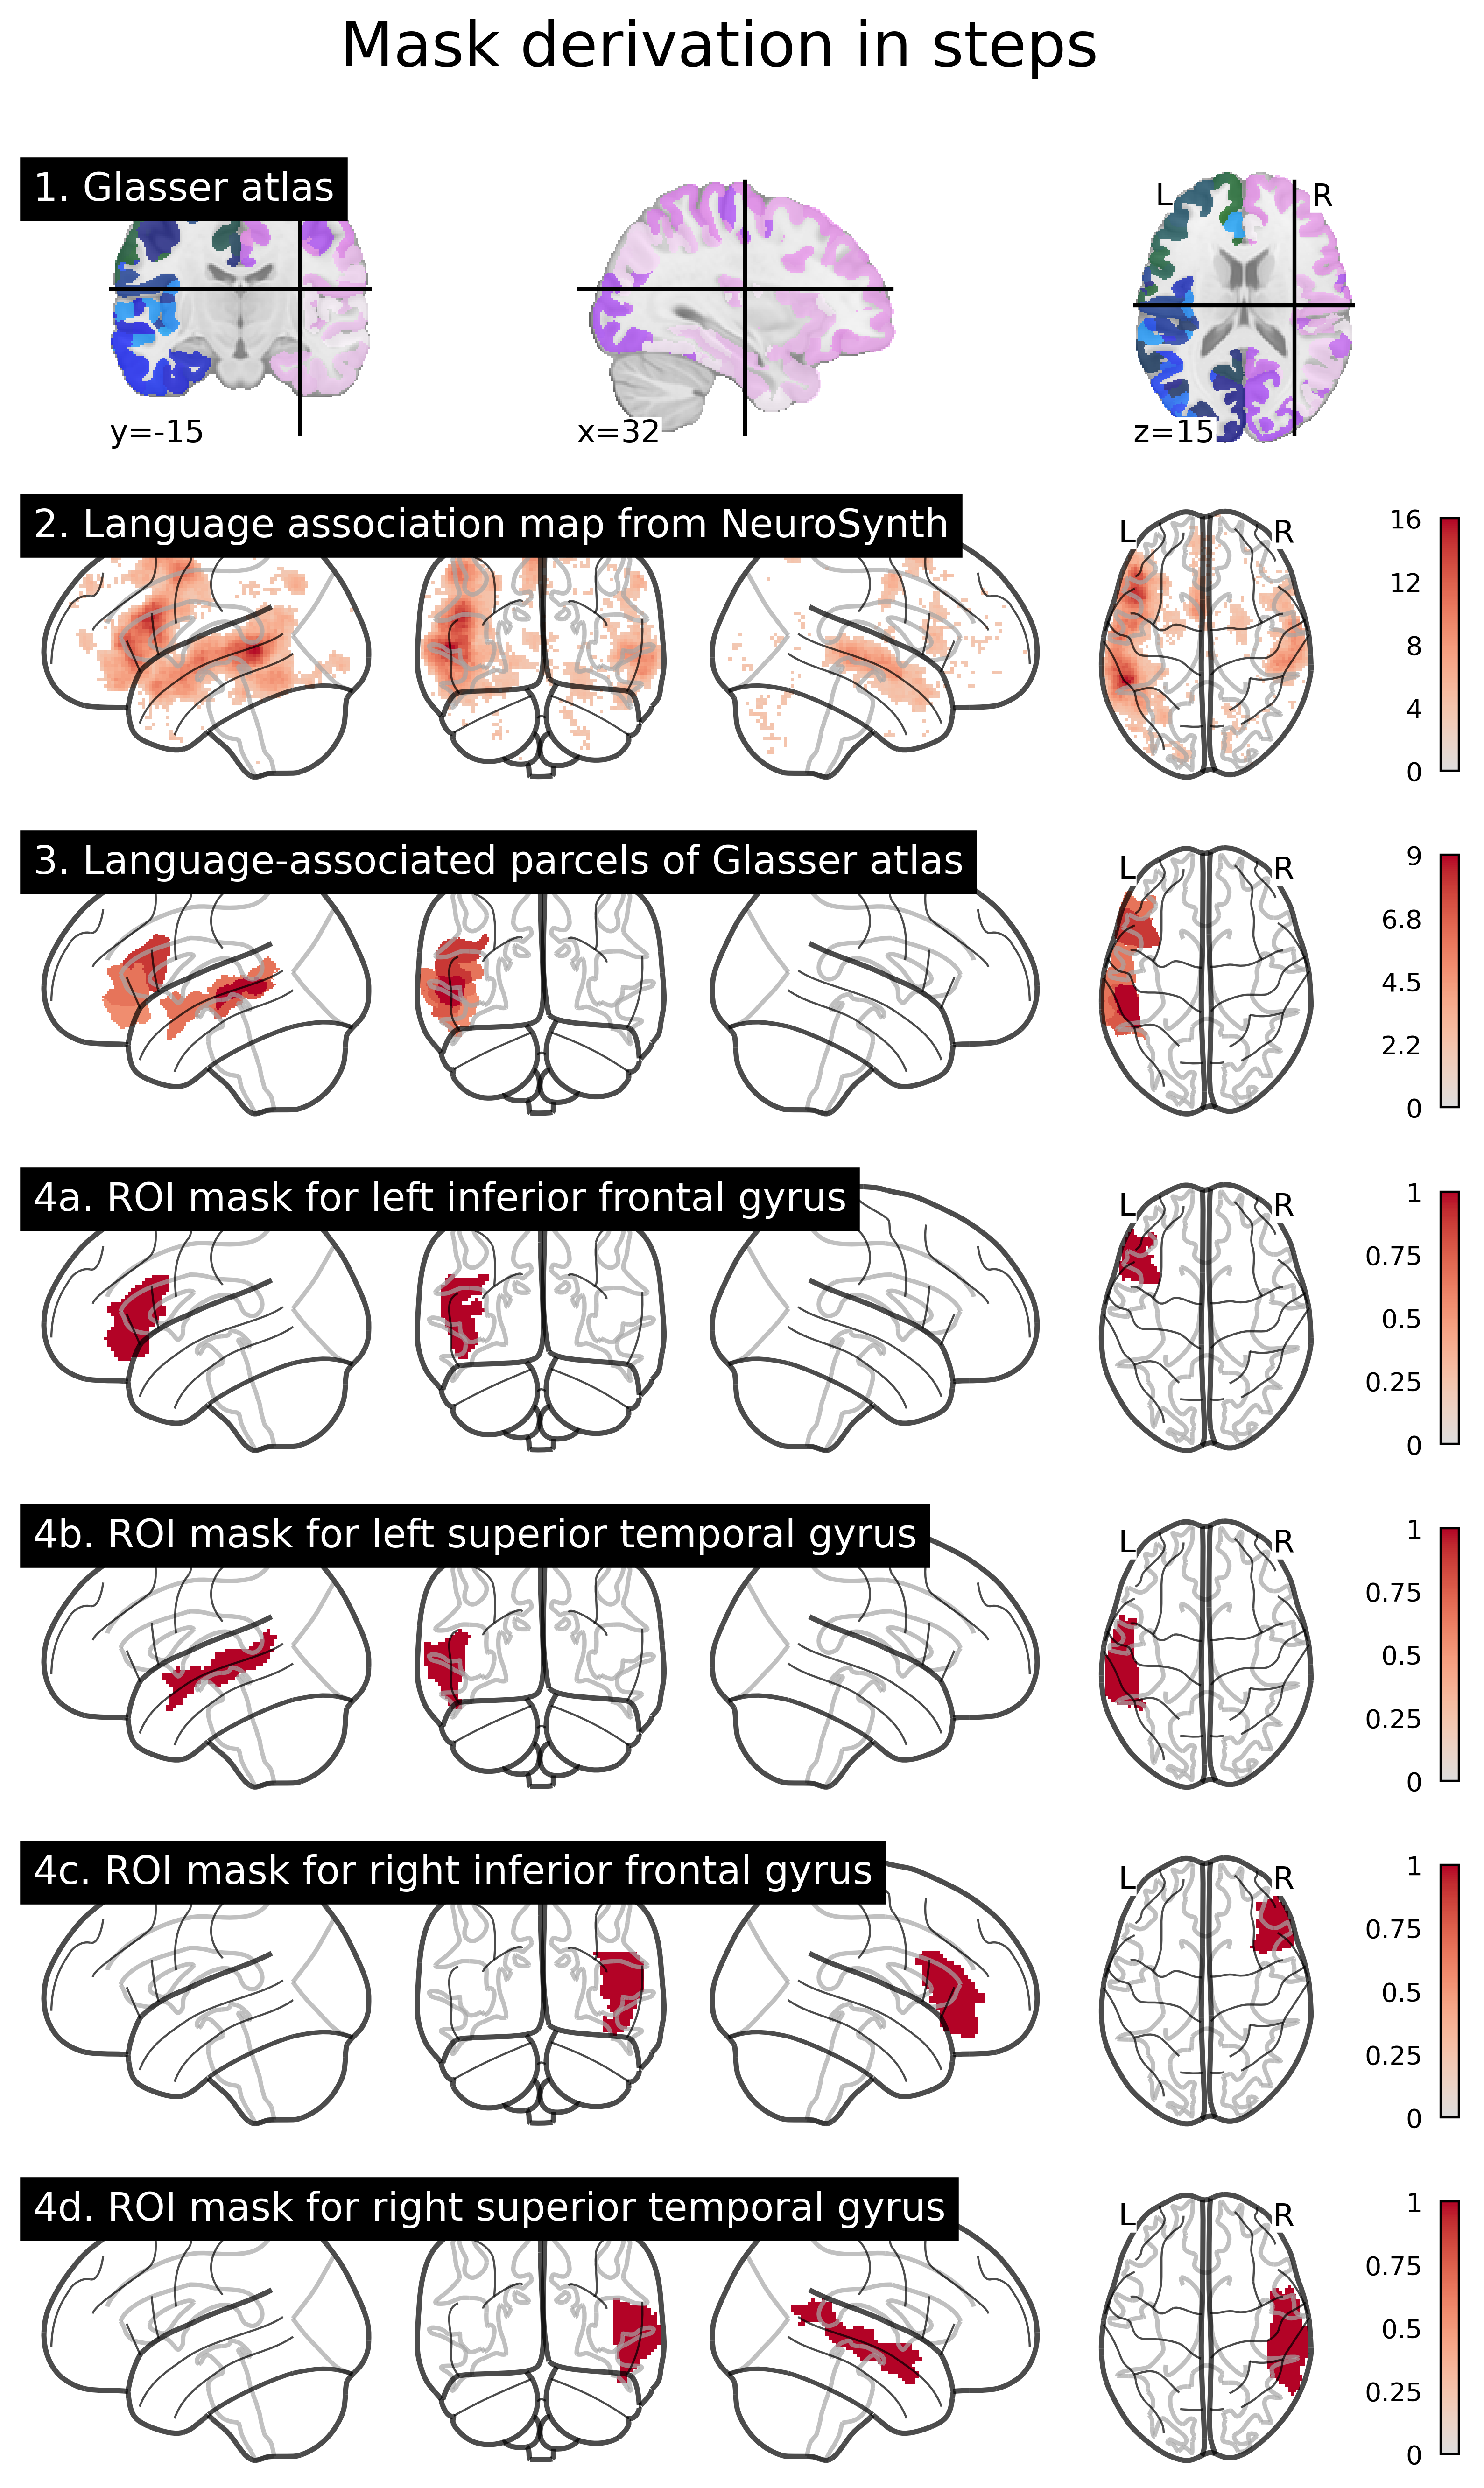

In [19]:
#explain process in figures
fig_args = {"figsize":(10,16),"dpi":400}

fig, ax = plt.subplots(7, 1, gridspec_kw={'height_ratios': [1]*7}, **fig_args)

fig.suptitle("Mask derivation in steps", y=0.93, fontsize=24)

plotting.plot_roi(image.load_img(atlas_in), title="1. Glasser atlas", axes=ax[0])
plotting.plot_glass_brain(image.load_img(lang_map), display_mode='lyrz', colorbar=True, cmap='coolwarm',
                                        title="2. Language association map from NeuroSynth", axes=ax[1])
plotting.plot_glass_brain(association_stat_img, display_mode='lyrz', colorbar=True, cmap='coolwarm', plot_abs=False,
                                        title="3. Language-associated parcels of Glasser atlas", axes=ax[2])
plotting.plot_glass_brain(image.load_img(os.path.join(work_path, "roi_lifg.nii.gz")), display_mode='lyrz', colorbar=True, cmap='coolwarm', plot_abs=False,
                                        title="4a. ROI mask for left inferior frontal gyrus", axes=ax[3])
plotting.plot_glass_brain(image.load_img(os.path.join(work_path, "roi_lstg.nii.gz")), display_mode='lyrz', colorbar=True, cmap='coolwarm', plot_abs=False,
                                        title="4b. ROI mask for left superior temporal gyrus", axes=ax[4])
plotting.plot_glass_brain(image.load_img(os.path.join(work_path, "roi_rifg.nii.gz")), display_mode='lyrz', colorbar=True, cmap='coolwarm', plot_abs=False,
                                        title="4c. ROI mask for right inferior frontal gyrus", axes=ax[5])
plotting.plot_glass_brain(image.load_img(os.path.join(work_path, "roi_rstg.nii.gz")), display_mode='lyrz', colorbar=True, cmap='coolwarm', plot_abs=False,
                                        title="4d. ROI mask for right superior temporal gyrus", axes=ax[6])

if save_all:
    plt.savefig(fname="/data/workspaces/lag/workspaces/lg-ukbiobank/projects/CONGRADS_rest/results/mask_derivation_glasser.png", bbox_inches="tight")